In [13]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
# Seed
random.seed(42)
np.random.seed(42)

In [15]:
# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'time_series', 'real', 'WTH')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints''time_series', 'real', 'WTH')
OUT_PATH = os.path.join(CURRENT_DIR, 'out' 'time_series', 'real', 'WTH')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'

In [16]:
df_data = pd.read_csv(os.path.join(DATA_PATH, 'WTH.csv'))
df_data

,date,Visibility,DryBulbFarenheit,DryBulbCelsius,WetBulbFarenheit,DewPointFarenheit,DewPointCelsius,RelativeHumidity,WindSpeed,WindDirection,StationPressure,Altimeter,WetBulbCelsius
0,1/1/2010 0:00,10.0,16,-9,13,7,-14,67,7,130,21.650000,30.35,-10.3
1,1/1/2010 1:00,10.0,16,-9,13,7,-14,67,5,150,21.640000,30.34,-10.3
2,1/1/2010 2:00,10.0,16,-9,13,7,-14,67,5,190,21.650000,30.35,-10.3
3,1/1/2010 3:00,10.0,16,-9,13,7,-14,67,7,180,21.650000,30.35,-10.3
4,1/1/2010 4:00,10.0,16,-9,14,9,-13,74,6,120,21.640000,30.34,-10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,12/31/2013 19:00,10.0,32,0,0,23,-5,0,0,0,21.478686,30.21,0.0
35060,12/31/2013 20:00,7.0,30,-1,0,25,-4,0,5,110,21.478686,30.21,0.0
35061,12/31/2013 21:00,5.0,30,-1,0,28,-2,0,0,0,21.478686,30.20,0.0
35062,12/31/2013 22:00,10.0,30,-1,0,28,-2,0,5,140,21.478686,30.18,0.0


In [17]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Visibility,35064.0,9.385894,2.034966,0.00,10.00,10.00,10.00,10.00
DryBulbFarenheit,35064.0,42.979438,17.068807,-15.00,30.00,43.00,55.00,86.00
DryBulbCelsius,35064.0,6.125000,9.420843,-26.00,-1.00,6.00,13.00,30.00
WetBulbFarenheit,35064.0,33.717944,12.689218,-16.00,25.00,33.00,44.00,61.00
DewPointFarenheit,35064.0,21.713068,14.507766,-29.00,12.00,19.00,32.00,59.00
DewPointCelsius,35064.0,-5.677247,8.037367,-34.00,-11.00,-7.00,0.00,15.00
RelativeHumidity,35064.0,49.843344,25.143403,0.00,29.00,48.00,69.00,100.00
WindSpeed,35064.0,5.651580,4.845549,0.00,0.00,6.00,8.00,38.00
WindDirection,35064.0,132.617528,102.147659,0.00,0.00,130.00,230.00,360.00
StationPressure,35064.0,21.530753,0.174853,20.66,21.42,21.56,21.67,21.88


In [18]:
df_data['date'] = pd.to_datetime(df_data['date'])

In [19]:
df_data.nunique()

date                 35064
Visibility              15
DryBulbFarenheit        57
DryBulbCelsius          57
WetBulbFarenheit        76
DewPointFarenheit       50
DewPointCelsius         50
RelativeHumidity        96
WindSpeed               32
WindDirection           38
StationPressure        120
Altimeter              155
WetBulbCelsius         361
dtype: int64

In [20]:
df_data.isna().sum()

date                 0
Visibility           0
DryBulbFarenheit     0
DryBulbCelsius       0
WetBulbFarenheit     0
DewPointFarenheit    0
DewPointCelsius      0
RelativeHumidity     0
WindSpeed            0
WindDirection        0
StationPressure      0
Altimeter            0
WetBulbCelsius       0
dtype: int64

In [21]:
df_data.duplicated().sum()

0

In [22]:
df_data.set_index('date', inplace=True)

In [23]:
date_diffs = df_data.index.diff().dropna()
date_diffs.value_counts()

date
0 days 01:00:00    35063
Name: count, dtype: int64

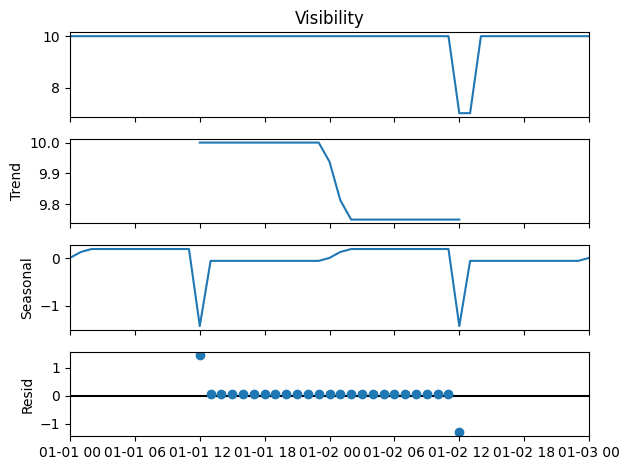

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(df_data['Visibility'][:49], model="additive")
decomposition.plot()
plt.show()

In [27]:
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    ),
    index=True
)